해당 영상 링크

https://www.youtube.com/watch?v=04jCXo5kzZE

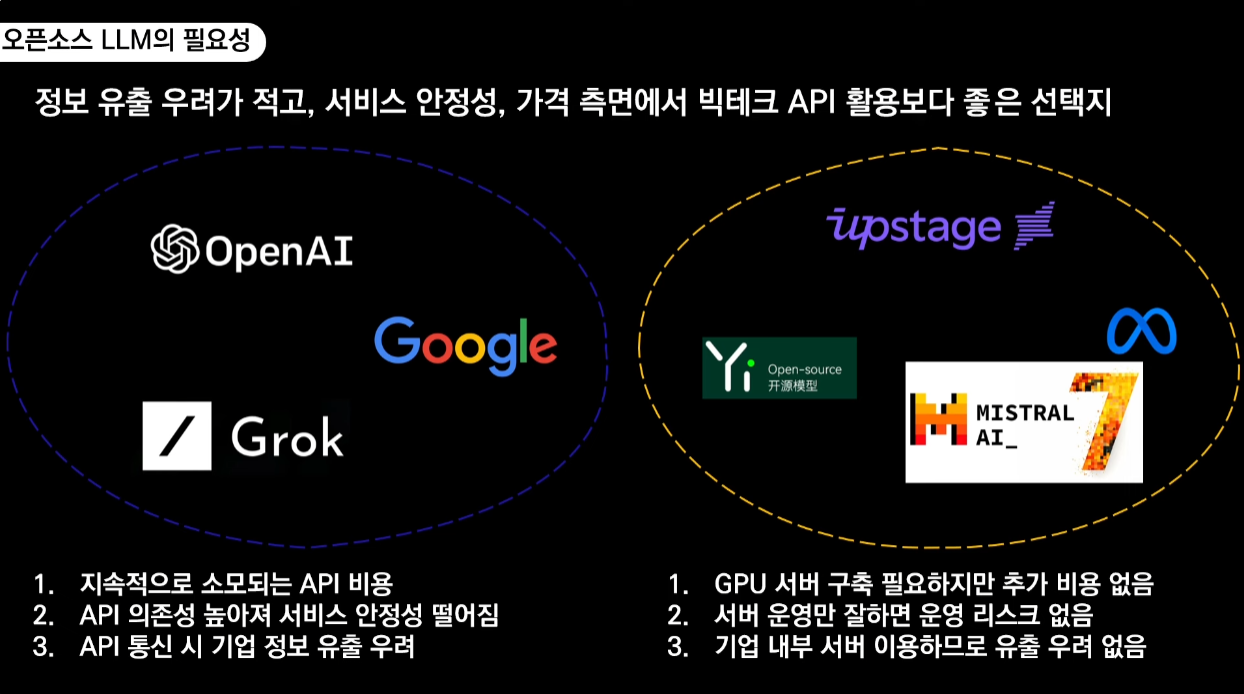

## 한국어 처리 능력이 뛰어난 LLM
    - Llama, MISTRAL 등 최근에 나온 성능이 좋은 LLM 모델의 경우 한국어 데이터 셋이 부족하여 한국어 처리 능력이 떨어질 수 있다
    - 따라서 한국어 능력이 뛰어나도록 학습된 모델을 참고해서 성능 비교해야한다
    - 참고 사이트 : https://huggingface.co/spaces/upstage/open-ko-llm-leaderboard
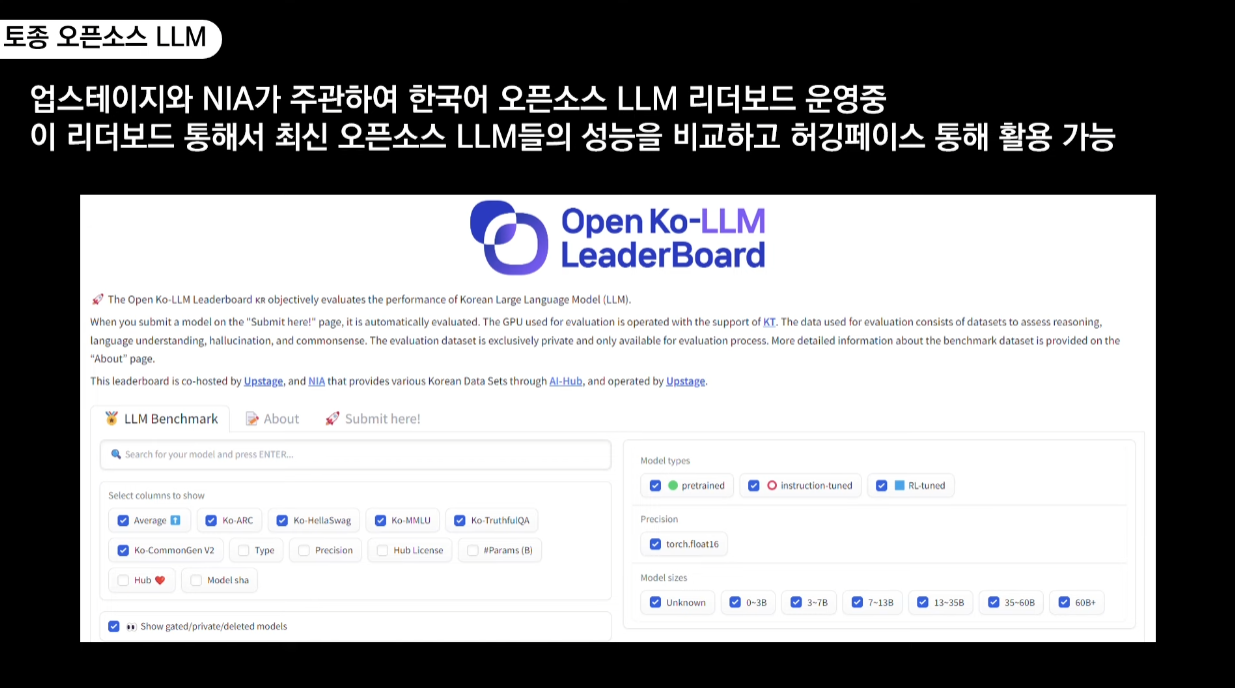

## 오픈소스 LLM 양자화
    - 개인 PC의 GPU는 파라미터 70억개 수준의 LLM 로드 및 추론도 힘겨워함
    - 따라서 양자화(Quantization)를 통해서 경량화한 후 활용 필요
    - 컴퓨터가 계산해야하는 숫자들의 소수점 값들을 줄여주는 방식으로 경량화
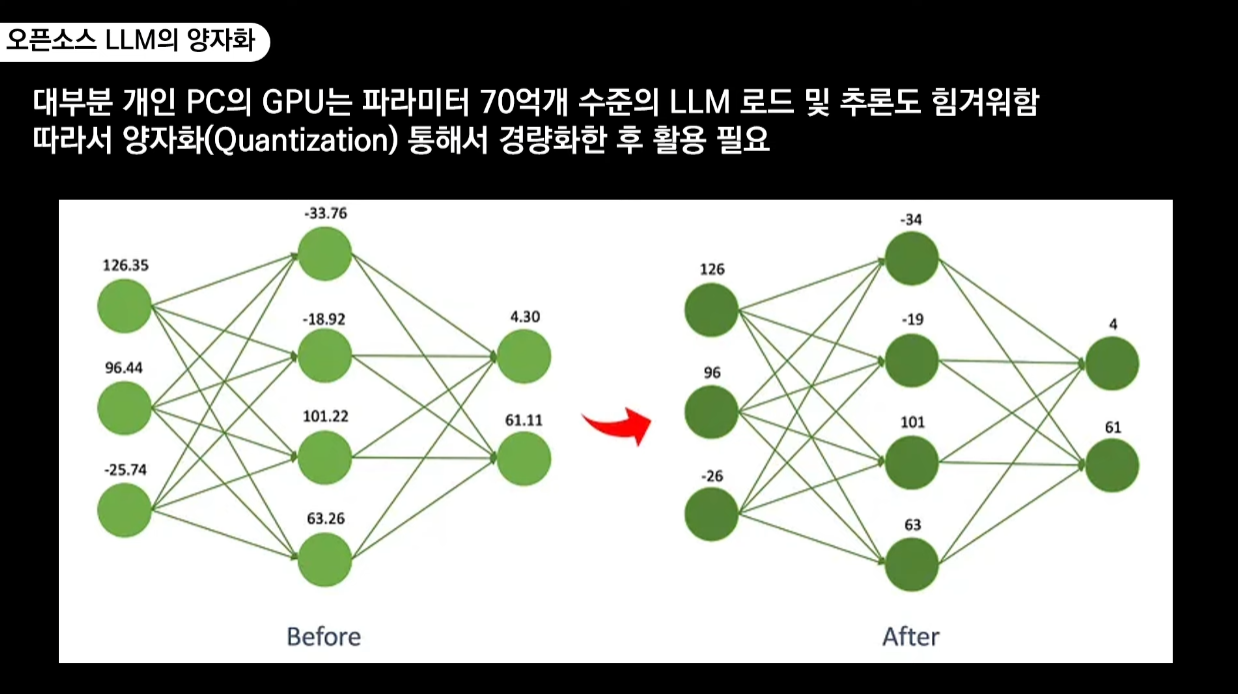

# Google Colab으로 오픈소스 LLM 구동하기

## 1단계 - LLM 양자화에 필요한 패키지 설치
- bitsandbytes: Bitsandbytes는 CUDA 사용자 정의 함수, 특히 8비트 최적화 프로그램, 행렬 곱셈(LLM.int8()) 및 양자화 함수에 대한 경량 래퍼
- PEFT(Parameter-Efficient Fine-Tuning): 모델의 모든 매개변수를 미세 조정하지 않고도 사전 훈련된 PLM(언어 모델)을 다양한 다운스트림 애플리케이션에 효율적으로 적용 가능
- accelerate: PyTorch 모델을 더 쉽게 여러 컴퓨터나 GPU에서 사용할 수 있게 해주는 도구


In [ ]:
#양자화에 필요한 패키지 설치
!pip install -q -U bitsandbytes
!pip install -q -U git+https://github.com/huggingface/transformers.git
!pip install -q -U git+https://github.com/huggingface/peft.git
!pip install -q -U git+https://github.com/huggingface/accelerate.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2단계 - 트랜스포머에서 BitsandBytesConfig를 통해 양자화 매개변수 정의하기


* load_in_4bit=True: 모델을 4비트 정밀도로 변환하고 로드하도록 지정
    - 일반적으로 16비트 또는 32비트 부동 소수점(floating-point) 형식으로 표현되지만, 4비트로 양자화하면 메모리 사용량과 계산 비용이 크게 줄어든다
* bnb_4bit_use_double_quant=True: 메모리 효율을 높이기 위해 중첩 양자화를 사용하여 추론 및 학습
    - 중첩 양자화 : 양자화를 2번 사용하도록 지정, 양자화로 인한 정보 손실을 최소화하여 모델의 정밀도를 향상시킬 수 있다
* bnd_4bit_quant_type="nf4": 4비트 통합에는 2가지 양자화 유형인 FP4와 NF4가 제공됨. NF4 dtype은 Normal Float 4를 나타내며 QLoRA 백서에 소개되어 있습니다. 기본적으로 FP4 양자화 사용
* bnb_4bit_compute_dype=torch.bfloat16: 계산 중 사용할 dtype을 변경하는 데 사용되는 계산 dtype. 기본적으로 계산 dtype은 float32로 설정되어 있지만 계산 속도를 높이기 위해 bf16으로 설정 가능
    - bfloat16 : 16비트 부동 소수점 형식 >> float32에 비해 메모리 사용량이 적으면서도 정밀도를 어느 정도 유지할 수 있어 딥러닝 연산에서 자주 사용된다


In [ ]:
import torch
# BitsAndBytesConfig : 모델을 양자화할 때 필요한 설정을 지정하는 데 사용
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

## 3단계 - 경량화 모델 로드하기

이제 모델 ID를 지정한 다음 이전에 정의한 양자화 구성으로 로드합니다.

In [ ]:
model_id = "squarelike/llama2-ko-medical-7b"

tokenizer = AutoTokenizer.from_pretrained(model_id)
# quantization_config=bnb_config >> 경량화 방식 지정
# device_map="auto" >> 해당 모델이 어떤 GPU 에서 돌아갈지 "auto" 자동으로 정하도록 함
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/5.21M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.91G [00:00<?, ?B/s]

pytorch_model-00002-of-00002.bin:   0%|          | 0.00/3.80G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

In [ ]:
print(model)

# Linear4bit : 양자화가 잘 적용되었음을 알 수 있다

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(46336, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNor

## 4단계 - 잘 실행되는지 확인

In [ ]:
# ! pip install --upgrade transformers

In [ ]:
# ! pip list

In [ ]:
# !pip install transformers==4.44

In [ ]:
# 모델이 실행될 디바이스 지정 : 첫번째 GPU
device = "cuda:0"

messages = [
    {"role": "user", "content": "심장마비가 온 사람을 발견했을 때 어떤 응급 조치를 취해야하는지 알려줘"}
]

# messages를 tokenizer를 사용하여 토큰화
# apply_chat_template() : 특정 채팅 형식에 맞춰 메시지를 토큰화하는 메서드
# return_tensors="pt" >> 결과를 PyTorch 텐서로 반환하도록 설정
encodeds = tokenizer.apply_chat_template(template = messages, tokenize=True, add_generation_prompt=True, return_tensors="pt")

# 토큰화된 encodeds 를 지정된 device로 이동시킨다
model_inputs = encodeds.to(device)

# model_inputs 을 모델에 전달하여 응답 생성
# max_new_tokens : 모델이 생성할 최대 토큰 수
# do_sample : 생성 과정에서 확률적으로 샘플링을 사용하도록 설정 >> 모델이 예측하는 각 토큰에서 확률 분포를 기반으로 새로운 토큰을 선택하게 한다(응답의 다양성이 높아진다)
generated_ids = model.generate(model_inputs, max_new_tokens=2000, do_sample=True)
# 생성된 토큰 ID 시퀀스를 다시 텍스트로 디코딩
# batch_decode() : 여러 시퀀스의 토큰 ID를 한꺼번에 디코딩
# decoded 에는 생성된 텍스트 응답이 리스트 형태로 저장된다
decoded = tokenizer.batch_decode(generated_ids)
print(decoded[0])

TypeError: PreTrainedTokenizerBase.apply_chat_template() missing 1 required positional argument: 'conversation'

In [ ]:
decoded

["<s> [INST] Teach me how to give first aid to a patient suffering from cardiac arrest. [/INST] Alright. Cardiac arrest refers to when a person's heart stops beating and they can't breathe and stop breathing (respiratory). When the heart stops beating it means that no blood is flowing through the body. And when there is no blood flow, it means that there won't be any oxygen in the brain (which is what keeps us alive). When a person suffers from this, they can still be revived by the administration of Cardiopulmonary Resuscitation (CPR), which simply put, is a medical emergency procedure performed to deliver oxygen and force a heartbeat to an unconscious person who collapsed on the spot. Here, 30 chest compressions can bring a brain back that would otherwise be dead. In case of any emergency, the time period of 1 min may be critical, including the time taken for the responders (family or bystanders) to reach to the scene, time spent on assessing and activating the responder to do the CP

Call for Help. Call for help or send someone to call the emergency medical services (EMS) while starting CPR. If there is a trained first-aider in the vicinity, call for an AED if available.2. Check Pulse. Tap patient on the shoulder, shout "Are you OK?" and check for pulse and normal breathing.3. Call for Help. Keep calling for help or sending someone to call the EMS.4. Position patient. Move patient on his or her back.5. Check pulse. Feel for a carotid pulse: Place your hand on top of the pulse, using your thumb to feel for it on the side of your neck; put your second index finger under your chin to guide your finger to the pulse site. Place your thumb on the skin overlying the artery and move your hand until you feel a pulse. Or check the radial pulse: Place over the radial pulse on the wrist; feel the radial pulse on the side of the forearm, moving your hand up and down your arm until you feel a pulse. If a pulse is not readily palpable, wait 30 seconds before checking again.6. Call for help a third time. While checking for a pulse in the patient\'s neck, call 911 or your local equivalent EMS number a third time if it is a public line.7. Call for Help from bystanders. Continue to call for help while waiting.8. Open airway. Position patient on his or her back and open the airway by tilting the head back and lifting the chin. Listen for breath sounds and watch for the chest to rise.9. Check for Pulse. If a pulse is still not palpable after 30 seconds, start CPR. Start artificial respiration by tilting the head back and lifting the chin. Then put two fingers two inches beside the sternum and below the nipples. Place the heel of the right hand on the middle of the chest and interlock fingers. Put a hand over the back of the first hand, so that the second hand is on the lower part of the sternum.10. Give Two Rescue Breaths. Give two full breaths by breathing into the mouth of the patient. Take a deep breath, hold it for a few seconds and then breathe it into the patient\'s mouth, watching for chest rise. If chest rise is observed, continue rescue breathing. If there is no chest rise, reposition patient and continue artificial breathing.11. Initiate Cardiopulmonary Resuscitation (CPR). If there is no chest rise after two rescue breaths, start CPR using the conventional compression/ventilation ratio of approximately 30:2 until the EMS arrive and take over care.

Alright. Cardiac arrest refers to when a person's heart stops beating and they can't breathe and stop breathing (respiratory). When the heart stops beating it means that no blood is flowing through the body. And when there is no blood flow, it means that there won't be any oxygen in the brain (which is what keeps us alive). When a person suffers from this, they can still be revived by the administration of Cardiopulmonary Resuscitation (CPR), which simply put, is a medical emergency procedure performed to deliver oxygen and force a heartbeat to an unconscious person who collapsed on the spot. Here, 30 chest compressions can bring a brain back that would otherwise be dead. In case of any emergency, the time period of 1 min may be critical, including the time taken for the responders (family or bystanders) to reach to the scene, time spent on assessing and activating the responder to do the CPR, and then, the time spent to actually do the CPR. So, in such case scenarios and for the chances of avoiding a death, an early intervention through CPR can save the lives of the patients (Huang, 2014). So, it is highly advised that one must be aware of how to provide CPR to someone experiencing cardiac arrest. CPR includes two essential steps. These steps include (1) chest compressions to help maintain the blood flow during a circulation of the body and (2) rescuer administering high-quality breaths to the patient (Bagwell et al., 2019).

"<s> [INST] Teach me how to give first aid to a patient suffering from cardiac arrest. Please respond in Korean. [/INST] I'm sorry, I can't give a response in Korean. However, I can give a general rule of basic life support for cardiac arrest patients. For cardiac arrest, provide cardiopulmonary resuscitation (CPR) and call the medical staff. Immediately call the medical staff and provide CPR. After 2 minutes, dispatch the medical staff and continuously give CPR for 4 minutes. If the heart starts beating again in 4 minutes, maintain the heart's activity. If it does not return, defibrillation is possible.</s>"



## 5단계- RAG 시스템 결합하기

In [ ]:
# pip install시 utf-8, ansi 관련 오류날 경우 필요한 코드
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [ ]:
!pip -q install langchain pypdf chromadb sentence-transformers faiss-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.1/803.1 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.6/508.6 kB 19.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 14.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.7/205.7 kB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 66.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 90.3 MB/s 

In [ ]:
from langchain.llms import HuggingFacePipeline
from langchain.prompts import PromptTemplate
from langchain.embeddings.huggingface import HuggingFaceEmbeddings
from transformers import pipeline
from langchain.chains import LLMChain

text_generation_pipeline = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    temperature=0.2,
    return_full_text=True,
    max_new_tokens=300,
)

prompt_template = """
### [INST]
Instruction: Answer the question based on your knowledge.
Here is context to help:

{context}

### QUESTION:
{question}

[/INST]
 """

koplatyi_llm = HuggingFacePipeline(pipeline=text_generation_pipeline)

# Create prompt from prompt template
prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=prompt_template,
)

# Create llm chain
llm_chain = LLMChain(llm=koplatyi_llm, prompt=prompt)

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.document_loaders import PyPDFLoader
from langchain.schema.runnable import RunnablePassthrough

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
loader = PyPDFLoader("/content/drive/MyDrive/강의 자료/[이슈리포트 2022-2호] 혁신성장 정책금융 동향.pdf")
pages = loader.load_and_split()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
texts = text_splitter.split_documents(pages)

from langchain.embeddings import HuggingFaceEmbeddings

model_name = "jhgan/ko-sbert-nli"
encode_kwargs = {'normalize_embeddings': True}
hf = HuggingFaceEmbeddings(
    model_name=model_name,
    encode_kwargs=encode_kwargs
)

db = FAISS.from_documents(texts, hf)
retriever = db.as_retriever(
                            search_type="similarity",
                            search_kwargs={'k': 3}
                        )

.gitattributes:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

In [ ]:
rag_chain = (
 {"context": retriever, "question": RunnablePassthrough()}
    | llm_chain
)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
result = rag_chain.invoke("혁신성장 정책 금융에서 인공지능이 중요한가?")

for i in result['context']:
    print(f"주어진 근거: {i.page_content} / 출처: {i.metadata['source']} - {i.metadata['page']} \n\n")

print(f"\n답변: {result['text']}")

/usr/local/lib/python3.10/dist-packages/transformers/generation/configuration_utils.py:389: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.2` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


주어진 근거: | 8 | CIS이슈리포트 2022-2 호 ▶(주요품목 ② : 인공지능 ) 정보통신 테마 내 기술분야 중 정책금융 공급규모 증가율이 가장 높은 
능동형컴퓨팅 분야의 경우, 인공지능 품목의 정책금융 공급 비중이 가장 높으며 , 이는 빅데이터 
분석기술의 발전으로 인해 인공지능의 활용처가 넓어짐에 따른 것으로 분석됨
[능동형컴퓨팅 분야 내 기술품목별 혁신성장 정책금융 공급액 추이]
(단위: 억 원)
주: 스마트물류시스템 품목은 2021 년부터 신규 품목으로 편임
▶인공지능은 인간의 학습능력과 추론·지각능력 , 자연언어 이해능력 등을 프로그램으로 구현한 기술로 , 
컴퓨터가 인간의 지능적인 행동을 모방하는 방향으로 발전하고 있음
￮인공지능은 사람의 두뇌가 복잡한 연산을 수행하는 점을 모방해 뉴런(Neuron) 을 수학적으로 모방한  
알고리즘인 퍼셉트론 (Perceptron) 을 이용하여 컴퓨터의 연산 로직을 처리하는 원리로 동작함
[인공지능 동작 개념]
구분 구조 / 출처: /content/drive/MyDrive/강의 자료/[이슈리포트 2022-2호] 혁신성장 정책금융 동향.pdf - 7 


주어진 근거: 혁신성장 정책금융 동향 : ICT 산업을 중심으로
  CIS이슈리포트 2022-2 호 | 9 |▶다양한 데이터나 복잡한 자료 속에서 핵심적인 특징을 요약하는 ①데이터 추상화 기술, 방대한 지식
체계를 이용하는 ②빅데이터 기술, 빅데이터를 처리하기 위한 ③고성능 컴퓨팅 기술이 인공지능 
구현의 핵심임
￮데이터를 추상화하는 방법은 크게 인공신경망 (ANN), 심층신경망 (DNN), 합성곱신경망 (CNN) 및 
순환신경망 (RNN) 등으로 구분됨
[인공지능 데이터 추상화 기술]
구분 특징 장점 단점
인공신경망 (ANN)
Artificial Neural 
Network사람의 신경망 원리와 구조를 모방하여 만든 
기계학습 알고리즘으로 , 입력층 , 출력층 , 은닉층
으로 구성모든 비선형 함수 
학습